In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [9]:
def part_a_pca_from_scratch():
    # Dataset (3 features, 10 samples)
    data = np.array([
        [2.5, 2.4, 0.5],
        [1.0, 0.7, 2.2],
        [2.0, 2.9, 1.9],
        [2.5, 2.2, 3.1],
        [3.1, 3.0, 2.3],
        [0.9, 2.7, 1.6]
    ])
    print("=== PART A: PCA from Scratch ===")
    print("Original data shape:", data.shape)

    # 1. Standardize
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    X_std = (data - mean) / std
    print("Standardized Data:\n", np.round(X_std, 4))

    # 2. Covariance matrix
    cov_mat = np.cov(X_std.T)
    print("\nCovariance Matrix:\n", np.round(cov_mat, 4))

    # 3. Eigen decomposition
    eig_vals, eig_vecs = np.linalg.eig(cov_mat)

    # 4. Sort eigenvalues & eigenvectors
    idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[idx]
    eig_vecs = eig_vecs[:, idx]

    print("\nEigenvalues:\n", np.round(eig_vals, 4))
    print("Eigenvectors (columns):\n", np.round(eig_vecs, 4))

    # 5. Select top k components (k=2)
    k = 2
    eig_vecs_k = eig_vecs[:, :k]

    # 6. Transform dataset
    X_pca = X_std @ eig_vecs_k
    print(f"\nTransformed Data (first {k} components):\n", np.round(X_pca, 4))

    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA from Scratch (Top 2 Components)')
    plt.grid(True)
    plt.show()

In [ ]:
def part_b_pca_iris():
    print("\n=== PART B: PCA on Iris Dataset ===")
    df = load_iris(as_frame=True)

    # Drop species column
    X = df.data.values
    y = df.target.values

    # Standardize
    X_std = StandardScaler().fit_transform(X)

    # Apply PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_std)

    print("\nPrincipal Components (loadings):\n", np.round(pca.components_, 4))
    print("\nExplained Variance Ratio:\n", np.round(pca.explained_variance_ratio_, 4))

    # Scatter plot of first two components
    plt.figure()
    for species in np.unique(y):
        mask = y == species
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=species)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Iris PCA (First Two Components)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def part_c_pca_wine_classification():
    print("\n=== PART C: PCA + Wine Dataset + Logistic Regression ===")
    wine = load_wine()
    X, y = wine.data, wine.target

    # Standardize
    X_std = StandardScaler().fit_transform(X)

    # PCA (2 components)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_std)

    print("Explained variance ratio (2 PCs):", np.round(pca.explained_variance_ratio_, 4))
    
    # Visualization
    plt.figure()
    for cls in np.unique(y):
        plt.scatter(X_pca[y == cls, 0], X_pca[y == cls, 1], label=f"Class {cls}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Wine Dataset PCA (2 Components)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Classification: full features
    X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)
    clf_full = LogisticRegression(max_iter=1000)
    clf_full.fit(X_train, y_train)
    acc_full = accuracy_score(y_test, clf_full.predict(X_test))

    # Classification: reduced features (2 PCs)
    X_train_p, X_test_p, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)
    clf_pca = LogisticRegression(max_iter=1000)
    clf_pca.fit(X_train_p, y_train)
    acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_p))

    print(f"\nAccuracy with 13 original features: {acc_full:.4f}")
    print(f"Accuracy with 2 PCA components:     {acc_pca:.4f}")

=== PART A: PCA from Scratch ===
Original data shape: (6, 3)
Standardized Data:
 [[ 0.5647  0.0984 -1.6588]
 [-1.1294 -1.9084  0.3086]
 [ 0.      0.6886 -0.0386]
 [ 0.5647 -0.1377  1.3502]
 [ 1.2423  0.8066  0.4243]
 [-1.2423  0.4525 -0.3858]]

Covariance Matrix:
 [[ 1.      0.5146  0.0967]
 [ 0.5146  1.     -0.1594]
 [ 0.0967 -0.1594  1.    ]]

Eigenvalues:
 [1.5186 1.0535 0.4279]
Eigenvectors (columns):
 [[-0.6929  0.2783  0.6652]
 [-0.7153 -0.1494 -0.6826]
 [ 0.0906  0.9488 -0.3026]]

Transformed Data (first 2 components):
 [[-0.6119 -1.4314]
 [ 2.1756  0.2636]
 [-0.4961 -0.1395]
 [-0.1704  1.4588]
 [-1.3993  0.6279]
 [ 0.5021 -0.7794]]


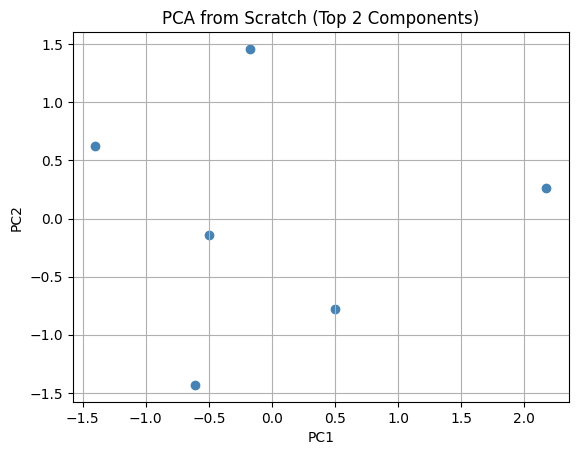

In [12]:
part_a_pca_from_scratch()


=== PART B: PCA on Iris Dataset ===

Principal Components (loadings):
 [[ 0.5211 -0.2693  0.5804  0.5649]
 [ 0.3774  0.9233  0.0245  0.0669]
 [ 0.7196 -0.2444 -0.1421 -0.6343]
 [-0.2613  0.1235  0.8014 -0.5236]]

Explained Variance Ratio:
 [0.7296 0.2285 0.0367 0.0052]


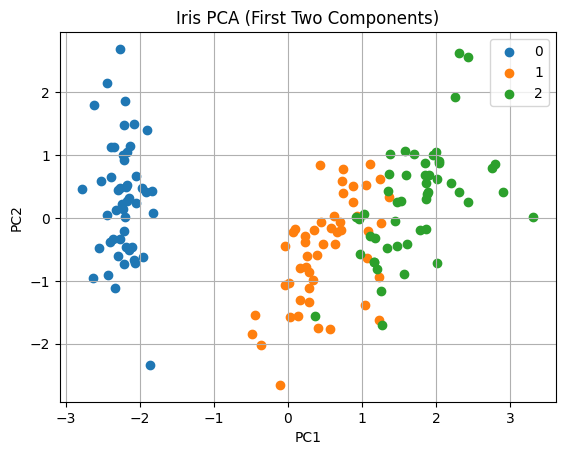

In [13]:
part_b_pca_iris()


=== PART C: PCA + Wine Dataset + Logistic Regression ===
Explained variance ratio (2 PCs): [0.362  0.1921]


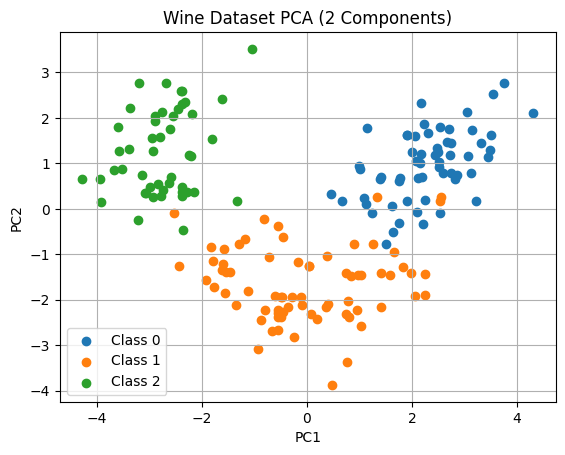


Accuracy with 13 original features: 1.0000
Accuracy with 2 PCA components:     1.0000


In [14]:
part_c_pca_wine_classification()